# Want to make the log(C/He) vs. Teff plot like Simon has in his various papers and then put my 4 DQpecs on top of it as like distinct symbols in some way.

In [1]:
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from astropy.io import fits
from glob import glob
from astropy.time import Time
from astropy import coordinates as coord
from astropy import units as u
from astropy import constants as const
from astropy import convolution as conv
from astropy.table import Table, Column
#import scipy.interpolate as scinterp
import time

sys.path.append('../')
sys.path.append('/Users/BenKaiser/Desktop/radial_velocity_calculations/')

In [2]:
import spec_plot_tools as spt
import cal_params as cp

In [3]:
input_path='/Users/BenKaiser/Desktop/MORDOR_Survey_paper/MORDOR_Survey_forPaper/Goodman_spectra_copy/'
dq_path='/Users/BenKaiser/Desktop/MORDOR_Survey_paper/outside_data/'
output_path='/Users/BenKaiser/Desktop/'

In [4]:
input_file='full_MORDOR_survey_1681141339_fullphotometry_fitparams.csv'
dq_file='20250408_MWDD_DQs_allparallax.csv'

In [5]:
input_table= Table.read(input_path+input_file)
dq_table=Table.read(dq_path+dq_file)

In [6]:
input_dqs=input_table[np.where(input_table['sp_type']=='DQpec')]

In [7]:
input_dqs.pprint()

       name                 designation           ... log_q note
----------------- ------------------------------- ... ----- ----
       LEHPM 1774 b'Gaia DR2 5140433498003756160' ...    --  0.0
MORDOR J0334-6348 b'Gaia DR2 4673772519470806144' ...    --  0.0
MORDOR J2053+1302 b'Gaia DR2 1761085712628042112' ...    --  0.0
MORDOR J2236-3635 b'Gaia DR2 6596688068617463808' ...    --  0.0


In [24]:
dq_subtable=dq_table[np.where(dq_table['logche']!=-8)]

Excluding the pretty obvious outliers

1744133121.817297


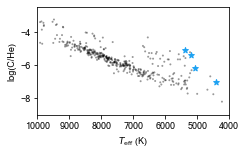

In [29]:
spt.start_mnras_fig(width_cols=1)
#plt.scatter(dq_table['teff'],dq_table['logche'],color='k',s=4,alpha=0.4,edgecolors='none')
plt.scatter(dq_subtable['teff'],dq_subtable['logche'],color='k',s=4,alpha=0.4,edgecolors='none')
plt.scatter(input_dqs['teff'],input_dqs['c/he'],color=cp.sp_type_colors['DQpec'],marker='*')
#plt.errorbar(input_dqs['teff'],input_dqs['c/he'],xerr=input_dqs['teff_err'],yerr=input_dqs['c/he_err'],color=cp.sp_type_colors['DQpec'],marker='*',linestyle='none')

plt.xlabel(r'$T_{\rm{eff}}$ (K)')
plt.ylabel('log(C/He)')
#plt.xlim(14000,4000)
plt.xlim(10000,4000)
plt.ylim(-9,-2.5)
#plt.legend()
#plt.show()

start = time.time()
print(start)
time_string=str(start).split('.')[0]
plt.savefig(output_path+"logche_vs_teff_"+time_string+'.pdf')#plt.grid(True)
